# Level 0 — one global day-ahead model for most households

**Question.** Which forecasting strategy should the team use for the day-ahead purchase, such that it works *fairly well for the majority of households*, not only for the portfolio total?

**Contract** (`utils.modeling.DAY_AHEAD`, shared with notebook 01). The 96 quarter-hours of UTC delivery day D are forecast from data strictly before **10:00 UTC on D-1**, ahead of the 12:00 local EPEX gate closure. Lead times are therefore 14–38 h, and yesterday's same slot is only known for slots before 10:00 UTC.

**Strategy.** One LightGBM model for all households. Every target and lag is divided by the household's mean load over the 28 days before the cutoff, so small and large households, and households with short histories, share one model. Features: same-slot lags known at the cutoff (D-1 where observed, D-2, D-3, D-7, D-14), 7-day and 4-week same-slot statistics, recent load level, past-only temperature, calendar, survey metadata. No realised target-day weather.

**Evaluation.** Expanding-window folds over all history since autumn 2020: two validation folds (summer 2022, winter 2022/23) select the model; the test window is scored once. Each fold trains only on delivery days fully observed before its first bid cutoff. Every model is scored on identical household rows.

Artifacts are produced by `uv run python -m utils.level0`.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
from utils.modeling import DAY_AHEAD

ART = ROOT / "artifacts" / "level0"
config = json.loads((ART / "config.json").read_text())
summary = pd.read_csv(ART / "household_summary.csv")
portfolio = pd.read_csv(ART / "portfolio_metrics.csv")
households = pd.read_parquet(ART / "household_metrics.parquet")
pv = pd.read_csv(ART / "pv_summary.csv")
horizon = pd.read_csv(ART / "horizon_mae.csv")
importance = pd.read_csv(ART / "feature_importance.csv")

WINNER, REF = config["selected_model"], "daily_weekly_ensemble"
LABELS = {WINNER: "Global LightGBM (selected)", REF: "Daily/weekly blend", "previous_day": "Latest same slot",
          "ridge_global": "Global Ridge", "lgb_global_l1": "Global LightGBM, L1 (median)",
          "slot_mean_7d": "7-day slot mean", "slot_median_7d": "7-day slot median", "previous_week": "Previous week"}
COLORS = {WINNER: "#2a78d6", REF: "#eb6834", "previous_day": "#1baf7a"}
INK, MUTED = "#0b0b0b", "#52514e"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": MUTED,
                     "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": .6, "axes.axisbelow": True,
                     "font.size": 10})

# The run must match the shared contract and must have selected on validation only.
assert config["contract"] == DAY_AHEAD.to_dict()
assert config["execution_mode"] == "full"
assert set(summary.fold) == {"validation", "val_summer", "val_winter", "test"}
print(f"Selected on validation: {WINNER}  |  rule: {config['selection_rule']}")
display(pd.DataFrame(config["folds"], index=["start", "end"]).T)

Selected on validation: lgb_global_l2  |  rule: median household nMAE on pooled validation folds among mean-forecast models


,start,end
val_summer,2022-05-29T00:00:00+00:00,2022-11-28T00:00:00+00:00
val_winter,2022-11-28T00:00:00+00:00,2023-05-29T00:00:00+00:00
test,2023-05-29T00:00:00+00:00,2024-02-28T00:00:00+00:00


## 1. Headline: test window (2023-05-29 → 2024-02-28)

*Household nMAE* is a household's MAE divided by its mean load, so households of every size count equally. *Beats blend* is the share of households whose MAE is lower than the daily/weekly persistence blend. Portfolio metrics sum all active households on identical rows.

In [2]:
def headline(fold):
    h = summary[summary.fold == fold].set_index("model")
    p = portfolio[portfolio.fold == fold].set_index("model")
    out = pd.DataFrame({
        "median household nMAE": h.median_household_nmae,
        "p90 household nMAE": h.p90_household_nmae,
        "households beating blend": h[f"share_households_beating_{REF}"],
        "portfolio WAPE": p.wape,
        "portfolio bias (kWh/15 min)": p.bias,
    }).rename(index=LABELS).sort_values("portfolio WAPE")
    return out

test = headline("test")
display(test.style.format({"median household nMAE": "{:.3f}", "p90 household nMAE": "{:.3f}",
                          "households beating blend": "{:.0%}", "portfolio WAPE": "{:.1%}",
                          "portfolio bias (kWh/15 min)": "{:+.2f}"}))

,median household nMAE,p90 household nMAE,households beating blend,portfolio WAPE,portfolio bias (kWh/15 min)
model,,,,,
Global LightGBM (selected),0.590,0.793,92%,12.3%,+1.28
Global Ridge,0.597,0.797,95%,14.0%,+0.40
Daily/weekly blend,0.651,0.869,0%,14.1%,-1.00
Latest same slot,0.711,0.955,1%,14.2%,-0.34
7-day slot mean,0.610,0.820,95%,15.3%,-1.08
Previous week,0.724,0.953,1%,18.9%,-1.61
7-day slot median,0.576,0.746,99%,22.0%,-17.52
"Global LightGBM, L1 (median)",0.542,0.707,100%,23.2%,-21.33


## 2. Does it work for the majority of households?

Each dot of the distribution is one household's skill against the blend, `1 − MAE_model / MAE_blend`. Positive means the global model is better for that household.

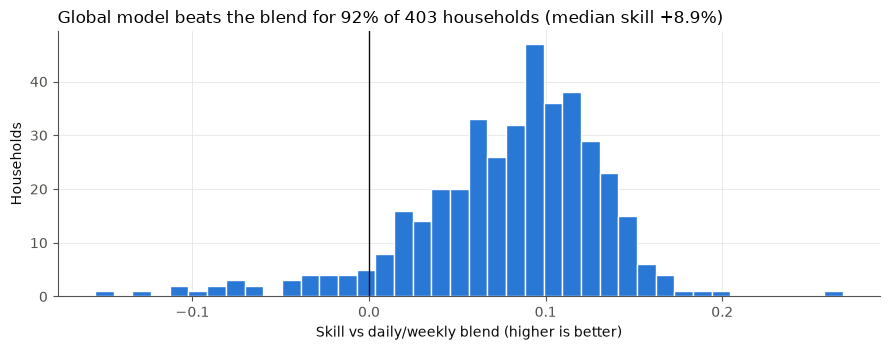

Households where the blend is still better (smallest skill first):


,Household_ID,PV_Status,mean_load,nmae_lgb_global_l2,nmae_daily_weekly_ensemble,skill_lgb_global_l2
91,112691,true,0.047,0.843,0.730,-0.155
40,1061228,true,0.372,0.838,0.741,-0.131
269,751078,unknown,0.259,0.546,0.491,-0.112
319,815461,true,0.031,1.495,1.353,-0.105
218,688105,true,0.393,0.351,0.319,-0.102
351,861116,true,0.179,0.708,0.653,-0.084
96,113987,unknown,0.109,0.585,0.539,-0.084
246,719010,unknown,0.263,0.656,0.608,-0.079


In [3]:
t = households[households.fold == "test"]
skill = t[f"skill_{WINNER}"]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(skill, bins=40, color=COLORS[WINNER], edgecolor="white", linewidth=1)
ax.axvline(0, color=INK, linewidth=1)
ax.set(xlabel="Skill vs daily/weekly blend (higher is better)", ylabel="Households",
       title=f"Global model beats the blend for {np.mean(skill > 0):.0%} of {len(skill)} households "
             f"(median skill {skill.median():+.1%})")
ax.title.set_ha("left"); ax.title.set_x(0)
plt.tight_layout(); plt.show()

worst = t.nsmallest(8, f"skill_{WINNER}")[["Household_ID", "PV_Status", "mean_load", f"nmae_{WINNER}", f"nmae_{REF}", f"skill_{WINNER}"]]
print("Households where the blend is still better (smallest skill first):")
display(worst.round(3))

## 2b. Sample forecasts

Days are chosen by rule, not by eye: the **median-error day** of winter (Dec–Feb), of summer (Jun–Aug) and of weekends, plus the **hardest day** of the test window (largest error of the selected model). Each panel shows the forecast that would have been submitted at 10:00 UTC the day before. The hardest day is typically a sudden cold spell: demand jumps above everything recent history suggests, which a weather-free model cannot anticipate; this is the case for day-ahead weather forecasts.

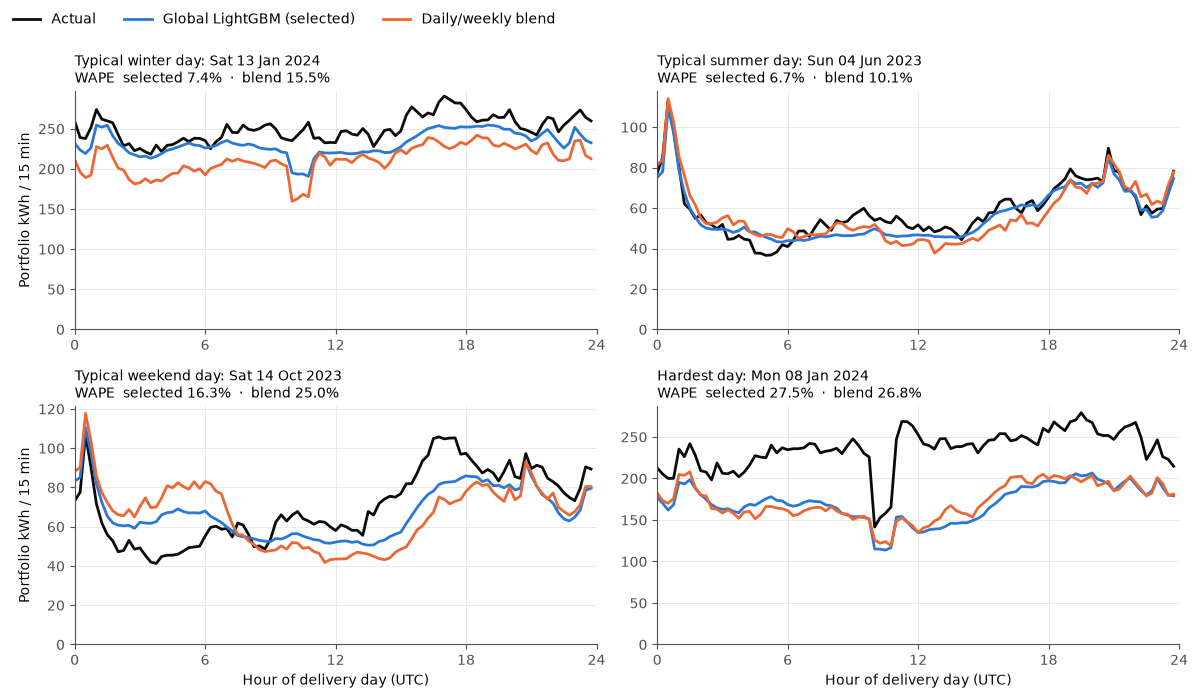

In [4]:
port = pd.read_parquet(ART / "test_portfolio_forecasts.parquet")
port["delivery_day"] = pd.to_datetime(port.delivery_day, utc=True)
port["hour"] = (port.horizon_step - 1) / 4
day_err = (port.assign(err=(port[WINNER] - port.actual).abs()).groupby("delivery_day").err.mean())
month, weekday = day_err.index.month, day_err.index.weekday

def median_day(mask):
    sub = day_err[mask]
    return (sub - sub.median()).abs().idxmin()

picks = {"Typical winter day": median_day(np.isin(month, [12, 1, 2])),
         "Typical summer day": median_day(np.isin(month, [6, 7, 8])),
         "Typical weekend day": median_day(weekday >= 5),
         "Hardest day": day_err.idxmax()}

def draw(ax, frame, x, ink_label=True):
    ax.plot(x, frame.actual, color=INK, linewidth=2, label="Actual")
    for m in (WINNER, REF):
        ax.plot(x, frame[m], color=COLORS[m], linewidth=2, label=LABELS[m])

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (title, day) in zip(axes.flat, picks.items()):
    d = port[port.delivery_day == day]
    draw(ax, d, d.hour)
    wape = {m: (d[m] - d.actual).abs().sum() / d.actual.sum() for m in (WINNER, REF)}
    ax.set_title(f"{title}: {day:%a %d %b %Y}\nWAPE  selected {wape[WINNER]:.1%}  ·  blend {wape[REF]:.1%}",
                 loc="left", fontsize=10)
    ax.set(xlim=(0, 24), xticks=range(0, 25, 6), ylim=(0, None))
for ax in axes[:, 0]: ax.set_ylabel("Portfolio kWh / 15 min")
for ax in axes[1]: ax.set_xlabel("Hour of delivery day (UTC)")
fig.legend(*axes[0, 0].get_legend_handles_labels(), frameon=False, loc="upper left", ncol=3)
plt.tight_layout(rect=(0, 0, 1, .95)); plt.show()

One winter week, forecast day by day (each day's 96 values were issued the previous morning). The sharp daily dip at 10:00–11:00 UTC is real demand, not missing meters (the household count is constant): average load per household drops by about a third every day, most likely a utility heat-pump blocking window (EVU-Sperrzeit, not confirmed by the data). Both models anticipate it from history.

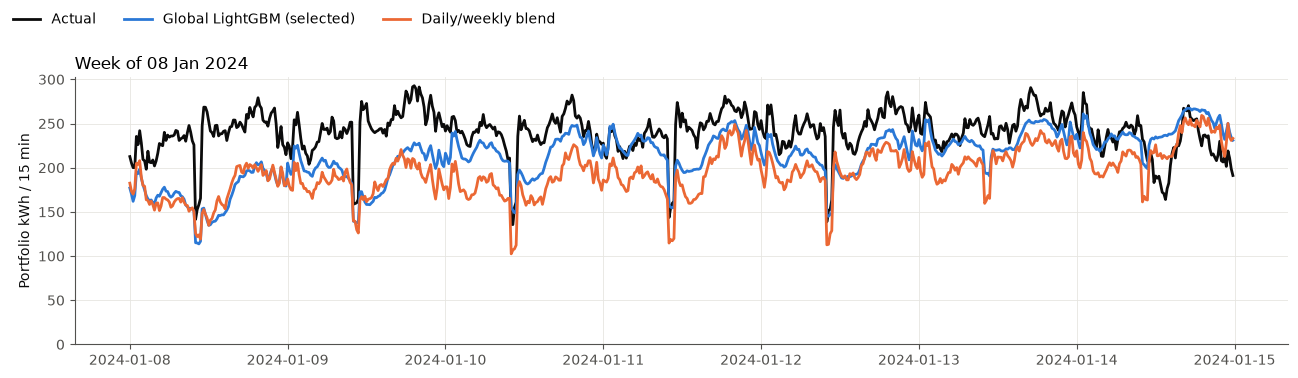

In [5]:
start = picks["Typical winter day"].normalize() - pd.Timedelta(days=picks["Typical winter day"].weekday())
week = port[(port.delivery_day >= start) & (port.delivery_day < start + pd.Timedelta(days=7))].copy()
week["t"] = week.delivery_day + pd.to_timedelta((week.horizon_step - 1) * 15, unit="min")
fig, ax = plt.subplots(figsize=(13, 3.8))
draw(ax, week, week.t)
ax.set(ylabel="Portfolio kWh / 15 min", ylim=(0, None), title=f"Week of {start:%d %b %Y}")
ax.title.set_ha("left"); ax.title.set_x(0)
fig.legend(*ax.get_legend_handles_labels(), frameon=False, loc="upper left", ncol=3)
plt.tight_layout(rect=(0, 0, 1, .9)); plt.show()

Single households are far noisier than the portfolio: heat-pump cycles and appliance spikes are not predictable a day ahead, so a good household forecast follows the *level and daily shape*, not individual spikes. The households below are the median-skill household of each PV group, on their own median-error winter day.

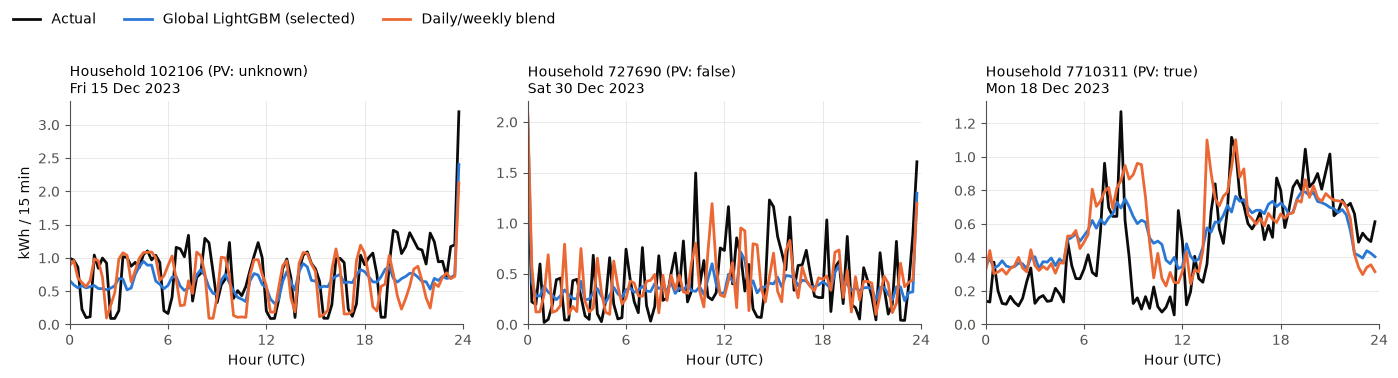

In [6]:
hh = pd.read_parquet(ART / "test_household_forecasts.parquet")
hh["delivery_day"] = pd.to_datetime(hh.delivery_day, utc=True)
hh["hour"] = (hh.horizon_step - 1) / 4
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, ((pid, status), g) in zip(axes, hh.groupby(["Household_ID", "PV_Status"])):
    errs = g.assign(err=(g[WINNER] - g.actual).abs()).groupby("delivery_day").err.mean()
    winter = errs[np.isin(errs.index.month, [12, 1, 2])]
    errs = winter if len(winter) else errs  # households without winter days fall back to all days
    day = (errs - errs.median()).abs().idxmin()
    d = g[g.delivery_day == day]
    draw(ax, d, d.hour)
    ax.set_title(f"Household {pid} (PV: {status})\n{day:%a %d %b %Y}", loc="left", fontsize=10)
    ax.set(xlim=(0, 24), xticks=range(0, 25, 6), xlabel="Hour (UTC)", ylim=(0, None))
axes[0].set_ylabel("kWh / 15 min")
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, loc="upper left", ncol=3)
plt.tight_layout(rect=(0, 0, 1, .88)); plt.show()

## 3. Is the result stable across seasons?

Validation is split into a summer and a winter fold; the test window spans summer through winter. The selected model leads clearly in winter and on test. **In the summer fold it does not:** its portfolio WAPE (12.1%) is slightly worse than the blend (11.6%) and Ridge (11.4%), with a small over-forecast, and it beats the blend for only about three quarters of households. Winter errors are several times larger in kWh, so the pooled validation still selects it.

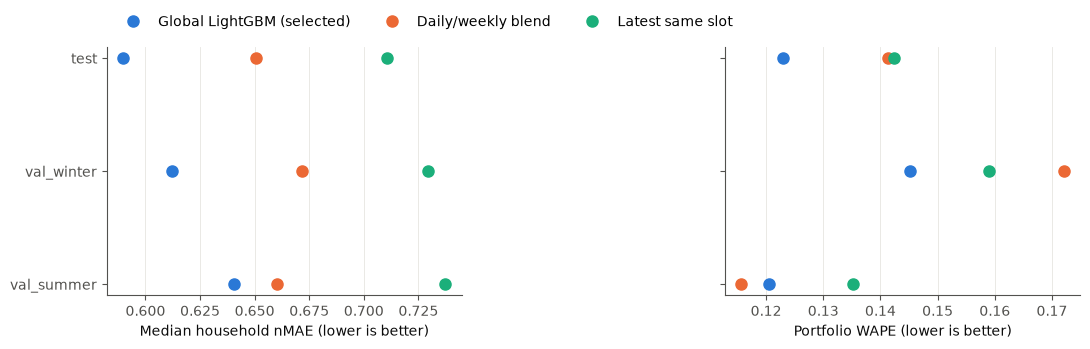

median household nMAE  \
           model                                               
val_summer Global LightGBM (selected)                  0.641   
           Daily/weekly blend                          0.660   
           Latest same slot                            0.737   
val_winter Global LightGBM (selected)                  0.612   
           Daily/weekly blend                          0.672   
           Latest same slot                            0.729   
test       Global LightGBM (selected)                  0.590   
           Daily/weekly blend                          0.651   
           Latest same slot                            0.711   

                                       p90 household nMAE  \
           model                                            
val_summer Global LightGBM (selected)               0.883   
           Daily/weekly blend                       0.922   
           Latest same slot                         0.996   
val_winter Global LightGBM (selected)               0.797   
           Daily/weekly blend                       0.890   
           Latest same slot                         0.960   
test       Global LightGBM (selected)               0.793   
           Daily/weekly blend                       0.869   
           Latest same slot                         0.955   

                                       households beating blend  \
           model                                                  
val_summer Global LightGBM (selected)                     0.744   
           Daily/weekly blend                             0.000   
           Latest same slot                               0.010   
val_winter Global LightGBM (selected)                     0.955   
           Daily/weekly blend                             0.000   
           Latest same slot                               0.039   
test       Global LightGBM (selected)                     0.923   
           Daily/weekly blend                             0.000   
           Latest same slot                               0.015   

                                       portfolio WAPE  \
           model                                        
val_summer Global LightGBM (selected)           0.121   
           Daily/weekly blend                   0.116   
           Latest same slot                     0.135   
val_winter Global LightGBM (selected)           0.145   
           Daily/weekly blend                   0.172   
           Latest same slot                     0.159   
test       Global LightGBM (selected)           0.123   
           Daily/weekly blend                   0.141   
           Latest same slot                     0.142   

                                       portfolio bias (kWh/15 min)  
           model                                                    
val_summer Global LightGBM (selected)                        1.533  
           Daily/weekly blend                               -1.135  
           Latest same slot                                 -0.446  
val_winter Global LightGBM (selected)                       -0.818  
           Daily/weekly blend                                2.043  
           Latest same slot                                  0.801  
test       Global LightGBM (selected)                        1.283  
           Daily/weekly blend                               -1.001  
           Latest same slot                                 -0.338

In [7]:
models = [WINNER, REF, "previous_day"]
folds = ["val_summer", "val_winter", "test"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (metric, frame, label) in zip(axes, [
        ("median_household_nmae", summary, "Median household nMAE"),
        ("wape", portfolio, "Portfolio WAPE")]):
    for m in models:
        values = [frame[(frame.fold == f) & (frame.model == m)][metric].item() for f in folds]
        ax.plot(values, folds, marker="o", markersize=8, linewidth=0, color=COLORS[m], label=LABELS[m])
    ax.set(xlabel=f"{label} (lower is better)")
    ax.grid(axis="y", visible=False)
axes[0].legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.02), ncol=3)
plt.tight_layout(); plt.show()
display(pd.concat({f: headline(f).loc[[LABELS[m] for m in models]] for f in folds}).round(3))

## 4. PV owners vs. non-PV households

PV status is the survey flag; `unknown` is kept as its own group, not treated as "no PV".

In [8]:
tab = pv[pv.model.isin([WINNER, REF])].pivot(index="PV_Status", columns="model",
                                            values="median_household_nmae").rename(columns=LABELS)
tab["households beating blend"] = pv[pv.model == WINNER].set_index("PV_Status")[f"share_households_beating_{REF}"]
tab["households"] = pv[pv.model == WINNER].set_index("PV_Status").households
display(tab.style.format({LABELS[WINNER]: "{:.3f}", LABELS[REF]: "{:.3f}", "households beating blend": "{:.0%}"}))

model,Daily/weekly blend,Global LightGBM (selected),households beating blend,households
PV_Status,,,,
false,0.624,0.567,96%,110
true,0.711,0.656,90%,131
unknown,0.614,0.558,91%,162


## 5. Error by slot of the delivery day

The vertical line marks 10:00 UTC: from that slot onward, yesterday's same slot was not yet observed at the cutoff, so persistence must fall back to D-2.

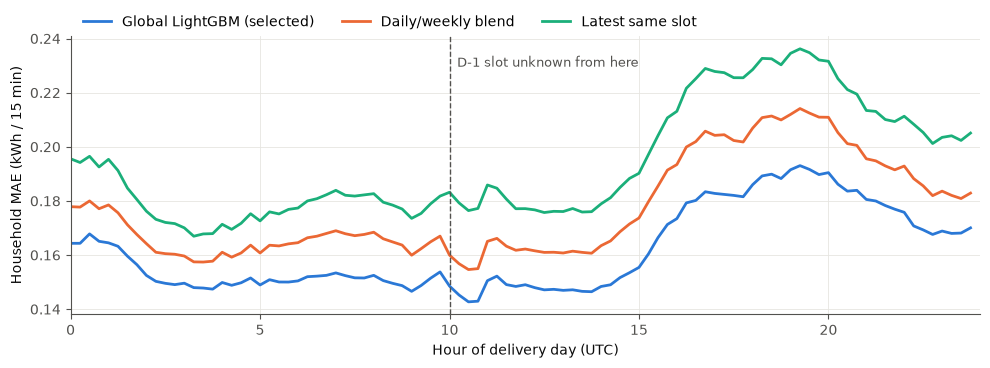

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.8))
hours = (horizon.horizon_step - 1) / 4
for m in models:
    ax.plot(hours, horizon[m], color=COLORS[m], linewidth=2, label=LABELS[m])
ax.axvline(DAY_AHEAD.data_cutoff_hour_utc, color=MUTED, linewidth=1, linestyle="--")
ax.text(DAY_AHEAD.data_cutoff_hour_utc + .2, ax.get_ylim()[1] * .97, "D-1 slot unknown from here",
        color=MUTED, va="top", fontsize=9)
ax.set(xlabel="Hour of delivery day (UTC)", ylabel="Household MAE (kWh / 15 min)", xlim=(0, 24))
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 1.12), ncol=3)
plt.tight_layout(); plt.show()

## 6. What the model relies on

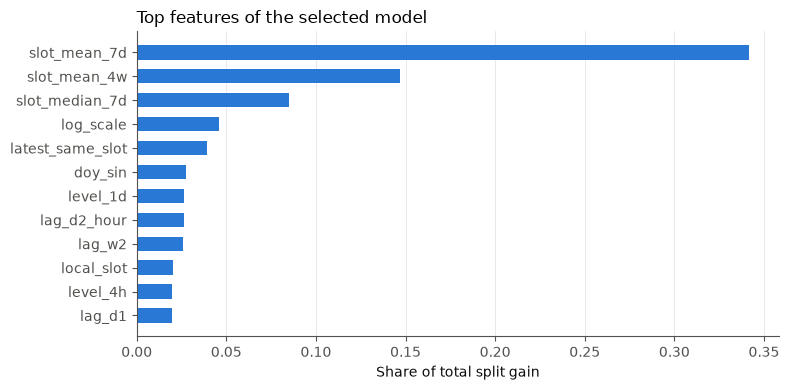

In [10]:
top = importance.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top.feature, top.gain / importance.gain.sum(), color=COLORS[WINNER], height=.6)
ax.set(xlabel="Share of total split gain", title="Top features of the selected model")
ax.grid(axis="y", visible=False); ax.title.set_ha("left"); ax.title.set_x(0)
plt.tight_layout(); plt.show()

## 7. Why not the median (L1) model?

The L1 model has the lowest *household* error because it predicts each household's typical value. Household load is right-skewed (short spikes), so typical values add up to well below the real total. Procurement buys the portfolio total, and only mean forecasts add up to the portfolio mean. The decision is made on validation alone:

In [11]:
val = headline("validation").loc[[LABELS["lgb_global_l1"], LABELS[WINNER], LABELS[REF]]]
display(val[["median household nMAE", "portfolio WAPE", "portfolio bias (kWh/15 min)"]].round(3))

,median household nMAE,portfolio WAPE,portfolio bias (kWh/15 min)
model,,,
"Global LightGBM, L1 (median)",0.554,0.231,-18.530
Global LightGBM (selected),0.621,0.138,0.353
Daily/weekly blend,0.670,0.157,0.461


In [12]:
w, b = test.loc[LABELS[WINNER]], test.loc[LABELS[REF]]
print(f"""DECISION
- Use {LABELS[WINNER]} as the Level 0 forecast. Selected on validation only.
- Test: beats the blend for {w['households beating blend']:.0%} of households; median household nMAE {w['median household nMAE']:.3f} vs {b['median household nMAE']:.3f}.
- Test portfolio WAPE {w['portfolio WAPE']:.1%} vs {b['portfolio WAPE']:.1%} for the blend, bias {w['portfolio bias (kWh/15 min)']:+.2f} kWh/15 min.
""")

DECISION
- Use Global LightGBM (selected) as the Level 0 forecast. Selected on validation only.
- Test: beats the blend for 92% of households; median household nMAE 0.590 vs 0.651.
- Test portfolio WAPE 12.3% vs 14.1% for the blend, bias +1.28 kWh/15 min.



## 8. Improving the recipe: Track A (validation only)

Sections 1–7 describe the Level 0 recipe. Track A tested, one change at a time, information the model did not yet use, all available before the 10:00 UTC D-1 cutoff:

- **Shared portfolio signals**: the whole portfolio's load in the 4 h and 24 h before the cutoff relative to its recent average. A cold spell hits every household at once, so this acts as a weather proxy that needs no weather data.
- **Morning trend**: each household's load from 00:00 to the cutoff on D-1 versus the same hours on D-2, plus the matching temperature change.
- **Holidays**: German public holidays and the Christmas period, for the delivery day and the lag days.
- **kWh weighting**: training rows weighted by household size (or size²), so the model optimises the kWh error that procurement pays for.
- **Rolling bias correction**: rescale each day by the recent portfolio actual/forecast ratio.

**These numbers come from the two validation folds only. The test window has not been scored for the new recipe;** that happens once, after the final recipe is fixed. Produced by `uv run python -m utils.track_a`.

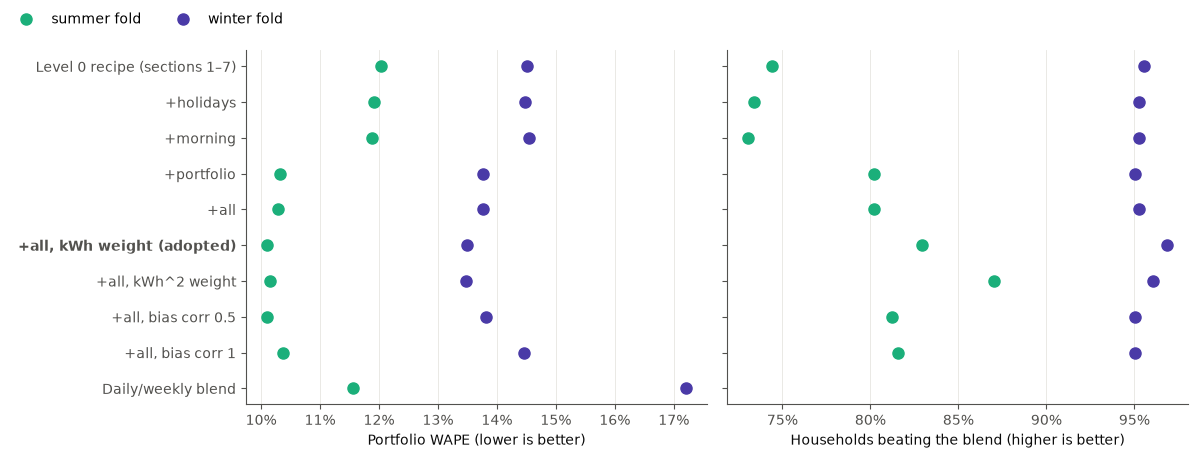

,summer WAPE,winter WAPE,pooled WAPE,households beating blend,median household nMAE,portfolio bias (kWh/15 min)
model,,,,,,
Level 0 recipe (sections 1–7),12.0%,14.5%,13.8%,93%,0.621,+0.35
+holidays,11.9%,14.5%,13.8%,93%,0.621,+0.38
+morning,11.9%,14.5%,13.8%,93%,0.621,+0.45
+portfolio,10.3%,13.8%,12.8%,93%,0.614,-0.09
+all,10.3%,13.8%,12.8%,94%,0.616,+0.03
"+all, kWh weight (adopted)",10.1%,13.5%,12.6%,96%,0.614,-0.23
"+all, kWh^2 weight",10.2%,13.5%,12.6%,95%,0.612,-0.20
"+all, bias corr 0.5",10.1%,13.8%,12.8%,94%,0.613,+0.25
"+all, bias corr 1",10.4%,14.5%,13.3%,93%,0.614,+0.47


In [13]:
track_a = pd.read_csv(ROOT / "artifacts" / "track_a" / "validation_results.csv")
BEAT = f"share_households_beating_{REF}"
ADOPTED = "+all, kWh weight"
order = ["base", "+holidays", "+morning", "+portfolio", "+all", ADOPTED, "+all, kWh^2 weight",
         "+all, bias corr 0.5", "+all, bias corr 1", REF]
names = {"base": "Level 0 recipe (sections 1–7)", REF: "Daily/weekly blend", ADOPTED: "+all, kWh weight (adopted)"}
FOLD_COLORS = {"val_summer": "#1baf7a", "val_winter": "#4a3aa7"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
y = np.arange(len(order))[::-1]
for ax, (metric, label) in zip(axes, [("wape", "Portfolio WAPE (lower is better)"),
                                      (BEAT, "Households beating the blend (higher is better)")]):
    for fold, color in FOLD_COLORS.items():
        values = track_a[track_a.fold == fold].set_index("model").loc[order, metric]
        if metric == BEAT:
            values = values.where(values.index != REF)  # the blend cannot beat itself
        ax.plot(values, y, marker="o", markersize=8, linewidth=0, color=color, label=fold.replace("val_", "") + " fold")
    ax.set(xlabel=label); ax.grid(axis="y", visible=False)
axes[0].set_yticks(y, [names.get(m, m) for m in order])
axes[0].get_yticklabels()[order.index(ADOPTED)].set_fontweight("bold")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, loc="upper left", ncol=2)
plt.tight_layout(rect=(0, 0, 1, .93)); plt.show()

pooled = track_a[track_a.fold == "validation"].set_index("model").loc[order]
wide = track_a.pivot(index="model", columns="fold", values="wape").loc[order]
table = pd.DataFrame({
    "summer WAPE": wide.val_summer, "winter WAPE": wide.val_winter, "pooled WAPE": pooled.wape,
    "households beating blend": pooled[BEAT].where(pooled.index != REF),
    "median household nMAE": pooled.median_household_nmae, "portfolio bias (kWh/15 min)": pooled.bias,
}).rename(index=names)
display(table.style.format({"summer WAPE": "{:.1%}", "winter WAPE": "{:.1%}", "pooled WAPE": "{:.1%}",
                            "households beating blend": "{:.0%}", "median household nMAE": "{:.3f}",
                            "portfolio bias (kWh/15 min)": "{:+.2f}"}, na_rep="—"))

**Reading.**

- **The shared portfolio signals carry almost all of the gain.** They improve both seasons and remove the summer weakness, which supports the weather-proxy explanation.
- **Weighting by household size adds a little more on top** and is adopted: pooled validation WAPE goes from 13.8% to 12.6%, and the share of households beating the blend from 93% to 96%. In summer the model now beats the blend (10.1% vs 11.6%).
- **Holidays and the morning trend are neutral.** They are kept because they are cheap and do no harm.
- **The rolling bias correction is not adopted**, since it makes winter worse.
- **Next:** Track B (model capacity on GPU: tuned gradient boosting, a neural network, CNN and GRU sequence models, and a combination of them) will be combined with these features. The final recipe is then chosen on validation and scored on the test window once.

## Limitations and next steps

- **Summer.** With the Level 0 recipe, the model is slightly worse than the blend and Ridge in the summer validation fold. Track A's shared portfolio signals fix this on validation (section 8); the test window has not yet been scored for the new recipe.
- **Weather.** Only past temperature is used. Archived day-ahead weather *forecasts* are needed before target-day weather can enter the model; realised weather would be leakage.
- **Level 2–3.** The winter validation fold's out-of-sample residuals are the natural calibration set for intervals and cost-aware (quantile) bids.